# RTU7 Hybrid FDD Example: Rule-Based vs. Machine Learning

This notebook demonstrates a hybrid approach to Fault Detection and Diagnostics (FDD) for a Rooftop Unit (RTU7). It runs **Open-FDD** rule-based detection first, then layers a **Machine Learning (ML)** model on top to compare traditional rigid fault signals against data-driven predictive signals on the exact same dataset.

### 🛠️ What This Notebook Does:
1. **Data Ingestion:** Loads the raw AHU sensor data, maps the columns, and establishes contiguous fan-run periods.
2. **Rule-Based FDD:** Runs standard Open-FDD logic (via `.yaml` rule files) to flag hard threshold violations (e.g., Supply Air Temperature operating completely outside the acceptable band).
3. **Machine Learning FDD:** Trains a predictive model (automatically baking off Decision Trees, Random Forests, and Extra Trees) on the clean, operating data. It learns what the SAT *should* be based on holistic variables like Outside Air Temp, Return Air Temp, Mixed Air Temp, and damper positions.
4. **Residual Thresholding:** Calculates the "residual" (the difference between the ML predicted SAT and the actual SAT). If that gap hits the 95th percentile of historical error, it throws an ML Fault flag.
5. **Zoomed-In Visualization:** Loops through continuous fan-on periods and generates stacked plots, allowing you to visually compare exactly when the Rule-Based logic fired vs. when the ML logic fired.

### 🧠 Why Compare Both?
* **Rule-Based Logic (The Strict Bouncer):** Checks exact, static boundaries. Highly transparent and great for catching catastrophic failures or extreme limit breaches.
* **Machine Learning Logic (The Early Warning):** Expectation vs. Reality. Highly dynamic and great for catching creeping inefficiencies, degraded coils, or slightly stuck dampers long before they get bad enough to trip a hard rule.

*By layering both, you combine the absolute certainty of rule-based FDD with the predictive, early-warning capabilities of machine learning.*

As shown belwo the script calculates the "residual" (the absolute difference between the Actual SAT and the ML Predicted SAT) for every single row.

It then uses .quantile(0.95) to find the 95th percentile of all those errors.

This means the script automatically draws a line and says, "Show me the worst 5% of predictions. Those are my faults."

In the print logs the model printed: Residual threshold: 7.246. That means for this specific dataset, any time the actual temperature deviated from the ML's prediction by more than 7.246 degrees, it triggered the red ML Fault shading.

## Install

The **next code cell** runs `%pip install open-fdd --upgrade` in this kernel and prints the PyPI package version.

Optional one-shot (terminal or other env):

```bash
pip install open-fdd pandas matplotlib scikit-learn jupyter ipykernel
```

In [ ]:
# Upgrade from PyPI (same environment as this kernel), then show installed version.
%pip install "open-fdd" --upgrade --quiet

import importlib.metadata

_dist = "open-fdd"
print(f"{_dist} (PyPI) version:", importlib.metadata.version(_dist))

In [1]:
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd

from openfdd_notebook_helpers_v2 import (
    load_dataset, run_openfdd, get_flag_cols, summarize_flags,
    compute_fan_runtime, weekly_fan_runtime, plot_weekly_fan_runtime,
    plot_series_with_fault_shading, plot_fault_pies, shade_flag_windows
)
from open_fdd.reports import summarize_all_faults, analyze_bounds_episodes, analyze_flatline_episodes

from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, r2_score

plt.style.use("seaborn-v0_8-whitegrid")

# USER CONFIGURATION

In [2]:
BASE_DIR = Path.cwd()
CSV_FILENAME = "AHU7.csv"
RULES_DIRNAME = "rules"

TIMESTAMP_SOURCE_COL = "timestamp"
TIMESTAMP_COL = "timestamp"
TIMEZONE_SUFFIX_REGEX = None
TIMESTAMP_FORMAT = "%Y-%m-%d %H:%M:%S"

COLUMN_MAP = {
    "Supply_Air_Temperature_Sensor": "SAT (°F)",
    "Mixed_Air_Temperature_Sensor": "MAT (°F)",
    "Outside_Air_Temperature_Sensor": "OAT (°F)",
    "Return_Air_Temperature_Sensor": "RAT (°F)",
    "Supply_Air_Static_Pressure_Sensor": "SA Static Press (inH₂O)",
    "Supply_Fan_Speed_Command": "SF Spd Cmd (%)",
}

TEMP_SENSOR_COLS = ["OAT (°F)", "RAT (°F)", "MAT (°F)", "SAT (°F)"]
PRESSURE_SENSOR_COLS = ["SA Static Press (inH₂O)"]

FAN_STATUS_COL = "SF Sts"
FAN_OUTPUT_COL = "SF Spd Cmd (%)"
FAN_OUTPUT_THRESHOLD = 10.0
REPORT_MOTOR_COL = FAN_STATUS_COL

# --- Open-FDD Flags ---
FAULT_SHADE_FLAG = "sat_operating_band_flag"
LEGACY_BOUNDS_FLAG = "bad_sensor_flag"
FLATLINE_FLAG = "flatline_flag"

# --- ML Configuration ---
MODEL_TARGET_COL = "SAT (°F)"
ML_FAULT_FLAG = "ml_residual_fault"
ML_PRED_COL = "sat_pred_ml"
ML_RESID_COL = "sat_residual_ml"
ML_ABS_RESID_COL = "sat_abs_residual_ml"

# Features to lag (Easy to tune here at the top)
LAG_COLS = ["OAT (°F)", "RAT (°F)", "MAT (°F)"]

BASE_FEATURE_COLS = [
    "OAT (°F)", "RAT (°F)", "MAT (°F)", "Eff SAT Sp (°F)", 
    "OA Damper Cmd (%)", "Clg Vlv Cmd (%)", "Prht Vlv Cmd (%)", 
    "SF Spd Cmd (%)", "SA Static Press (inH₂O)"
]

OPTIONAL_FEATURE_COLS = ["Occupancy", "Econ Ena"]

# --- Plotting ---
FAULT_SHADE_ALPHA = 0.18
FIGSIZE_WIDE = (16, 6)
FIGSIZE_MED = (16, 4)

CSV_PATH = BASE_DIR / CSV_FILENAME
RULES_DIR = BASE_DIR / RULES_DIRNAME

ML_FAULT_QUANTILE = 0.95  # 0.90 for more faults, 0.99 for fewer faults

### Column map resolvers (Brick TTL vs manifest)

`run_openfdd` accepts `column_map_resolver=...`. The default is **`BrickTtlColumnMapResolver`**. For manifest-only mapping (Haystack / 223P / DBO, etc.), use **`ManifestColumnMapResolver`** with YAML/JSON from `load_column_map_manifest`. See **`examples/column_map_resolver_workshop/`**.

In [ ]:
from open_fdd.engine import BrickTtlColumnMapResolver, ManifestColumnMapResolver, load_column_map_manifest

_default_resolver = BrickTtlColumnMapResolver()
print("Default resolver type:", type(_default_resolver).__name__)

_manifest_resolver = ManifestColumnMapResolver()
print("Manifest resolver type:", type(_manifest_resolver).__name__)

In [ ]:
import tempfile
from pathlib import Path

import yaml
from open_fdd.engine import load_column_map_manifest

with tempfile.TemporaryDirectory() as td:
    manifest_path = Path(td) / "column_map.yaml"
    manifest_path.write_text(yaml.safe_dump(COLUMN_MAP, sort_keys=False), encoding="utf-8")
    loaded = load_column_map_manifest(manifest_path)
assert loaded == COLUMN_MAP
print("COLUMN_MAP manifest round-trip OK:", len(loaded), "keys")

In [3]:
# Load Dataset
df = load_dataset(
    csv_path=CSV_PATH,
    timestamp_source_col=TIMESTAMP_SOURCE_COL,
    timestamp_col=TIMESTAMP_COL,
    timestamp_format=TIMESTAMP_FORMAT,
    timezone_suffix_regex=TIMEZONE_SUFFIX_REGEX,
)

# Run Open-FDD
df_result = run_openfdd(
    df=df,
    rules_dir=RULES_DIR,
    timestamp_col=TIMESTAMP_COL,
    column_map=COLUMN_MAP,
)

# Compute Fan Runtime
df_result, fan_logic_used, total_fan_run_hours = compute_fan_runtime(
    df_result=df_result,
    timestamp_col=TIMESTAMP_COL,
    fan_status_col=FAN_STATUS_COL,
    fan_output_col=FAN_OUTPUT_COL,
    fan_output_threshold=FAN_OUTPUT_THRESHOLD,
)

c:\Users\ben\OneDrive\Desktop\BensOpenClawTesting\examples\AHU\openfdd_notebook_helpers_v2.py:213: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_result["fan_on"] = status_bool.ffill().fillna(False).astype(bool)


In [4]:
# Create lags
for col in LAG_COLS:
    if col in df_result.columns:
        df_result[f"{col}_lag1"] = df_result[col].shift(1)

# Keep only optional columns with decent coverage
optional_keep = []
for col in OPTIONAL_FEATURE_COLS:
    if col in df_result.columns:
        non_null_frac = df_result[col].notna().mean()
        if non_null_frac >= 0.50:
            optional_keep.append(col)

FEATURE_COLS = BASE_FEATURE_COLS + optional_keep + [f"{c}_lag1" for c in LAG_COLS if f"{c}_lag1" in df_result.columns]

print("Using features:", FEATURE_COLS)

model_df = df_result.copy()

# Restrict to fan-on rows first
model_df = model_df.loc[model_df["fan_on"] == True].copy()

# Only require target + chosen features
required_cols = [MODEL_TARGET_COL] + FEATURE_COLS
model_df = model_df.dropna(subset=required_cols).copy()

print("Rows after fan_on filter:", int((df_result["fan_on"] == True).sum()))
print("Rows after dropna:", len(model_df))

X = model_df[FEATURE_COLS].copy()
y = model_df[MODEL_TARGET_COL].copy()

print("X shape:", X.shape)
print("y shape:", y.shape)

if len(X) < 40:
    raise ValueError(f"Not enough rows left for ML after filtering: {len(X)}")

Using features: ['OAT (°F)', 'RAT (°F)', 'MAT (°F)', 'Eff SAT Sp (°F)', 'OA Damper Cmd (%)', 'Clg Vlv Cmd (%)', 'Prht Vlv Cmd (%)', 'SF Spd Cmd (%)', 'SA Static Press (inH₂O)', 'OAT (°F)_lag1', 'RAT (°F)_lag1', 'MAT (°F)_lag1']
Rows after fan_on filter: 1379
Rows after dropna: 1277
X shape: (1277, 12)
y shape: (1277,)


In [5]:
# Make folds adapt to available row count
n_splits = min(4, max(2, len(X) // 50))
print("Using n_splits =", n_splits)

tscv = TimeSeriesSplit(n_splits=n_splits)

tree_search = GridSearchCV(
    DecisionTreeRegressor(random_state=42),
    param_grid={
        "max_depth": [4, 6, 8, 10],
        "min_samples_leaf": [5, 10, 20],
    },
    scoring="neg_mean_absolute_error",
    cv=tscv,
    n_jobs=-1,
)

rf_search = GridSearchCV(
    RandomForestRegressor(random_state=42, n_jobs=-1),
    param_grid={
        "n_estimators": [100, 200],
        "max_depth": [6, 10, None],
        "min_samples_leaf": [5, 10],
    },
    scoring="neg_mean_absolute_error",
    cv=tscv,
    n_jobs=-1,
)

et_search = GridSearchCV(
    ExtraTreesRegressor(random_state=42, n_jobs=-1),
    param_grid={
        "n_estimators": [100, 200],
        "max_depth": [6, 10, None],
        "min_samples_leaf": [5, 10],
    },
    scoring="neg_mean_absolute_error",
    cv=tscv,
    n_jobs=-1,
)

tree_search.fit(X, y)
rf_search.fit(X, y)
et_search.fit(X, y)

Using n_splits = 4


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",ExtraTreesReg...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [6, 10, ...], 'min_samples_leaf': [5, 10], 'n_estimators': [100, 200]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_mean_absolute_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",TimeSeriesSpl...est_size=None)
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold an

In [6]:
searches = {
    "Decision Tree": tree_search,
    "Random Forest": rf_search,
    "Extra Trees": et_search,
}

results = []
for name, search in searches.items():
    best_model = search.best_estimator_
    pred = best_model.predict(X)

    results.append({
        "model": name,
        "best_params": search.best_params_,
        "mae_full_fit": mean_absolute_error(y, pred),
        "r2_full_fit": r2_score(y, pred),
    })

results_df = pd.DataFrame(results).sort_values("mae_full_fit")
display(results_df)

# Select best model
best_name = results_df.iloc[0]["model"]
best_search = searches[best_name]
best_model = best_search.best_estimator_

print(f"\\nSelected model: {best_name}")
print(f"Best params: {best_search.best_params_}")

# Generate Predictions & Residuals
model_df[ML_PRED_COL] = best_model.predict(X)
model_df[ML_RESID_COL] = model_df[MODEL_TARGET_COL] - model_df[ML_PRED_COL]
model_df[ML_ABS_RESID_COL] = model_df[ML_RESID_COL].abs()

# Generate ML Fault Flag
resid_threshold = model_df[ML_ABS_RESID_COL].quantile(ML_FAULT_QUANTILE)
model_df[ML_FAULT_FLAG] = (model_df[ML_ABS_RESID_COL] > resid_threshold).astype(int)

print(f"Residual threshold: {round(resid_threshold, 3)}")
print(f"ML fault count: {int(model_df[ML_FAULT_FLAG].sum())}")

# Merge back to main dataframe
ml_cols_to_add = [ML_PRED_COL, ML_RESID_COL, ML_ABS_RESID_COL, ML_FAULT_FLAG]
for col in ml_cols_to_add:
    df_result[col] = pd.NA

df_result.loc[model_df.index, ml_cols_to_add] = model_df[ml_cols_to_add]

,model,best_params,mae_full_fit,r2_full_fit
1,Random Forest,"{'max_depth': None, 'min_samples_leaf': 10, 'n...",1.733990,0.919395
0,Decision Tree,"{'max_depth': 10, 'min_samples_leaf': 20}",2.119491,0.898304
2,Extra Trees,"{'max_depth': 6, 'min_samples_leaf': 10, 'n_es...",2.394262,0.881374


\nSelected model: Random Forest
Best params: {'max_depth': None, 'min_samples_leaf': 10, 'n_estimators': 200}
Residual threshold: 7.246
ML fault count: 64


### Rule-Based vs. Machine Learning Fault Detection

These two methods are fundamentally different in how they "think," making them a powerful combination when layered together.

**1. Rule-Based Faults (The "If-This-Then-That" Approach)**
Rule-based logic relies on hardcoded thresholds written by an engineer (like the limits in a `.yaml` file). 
* **How it works:** It checks strict, static boundaries. *(Example: IF Supply Air Temp > 75°F AND Cooling Valve is 100% open, THEN trigger a fault.)*
* **Pros:** 100% transparent. When a rule fires, you know exactly what mechanical condition caused it. 
* **Cons:** Incredibly rigid. If your rule threshold is 75°F, the system will happily ignore an RTU that is blowing 74.9°F air, even if that is highly abnormal for the current weather.

**2. Machine Learning Faults (The "Expectation vs. Reality" Approach)**
Machine learning doesn't use hardcoded temperature limits. Instead, it learns the unique baseline behavior of that specific piece of equipment based on historical data.
* **How it works:** The model looks at the current holistic conditions (Outside Air Temp, Return Air Temp, Damper %, etc.) and predicts what the SAT *should* be right now. If the actual SAT deviates too far from that prediction, it flags a fault.
* **Pros:** Highly dynamic. It catches sneaky, creeping inefficiencies—like a degrading cooling coil or a slightly stuck damper—long before the temperature gets bad enough to trip a hard rule.
* **Cons:** It's a "black box." It tells you the equipment is acting highly abnormal, but it doesn't always explicitly tell you *which* mechanical part is broken. 

**Reading the Plots:**
* **Rule-Only Shading:** A sensor hit a catastrophic, extreme limit. 
* **ML-Only Shading:** The unit is operating inefficiently, but hasn't fully failed yet (Early Warning).
* **Both Shaded:** The unit is completely broken, and both the strict logic and the predictive model agree.

Found 20 continuous fan-on periods (ignoring tiny blips).


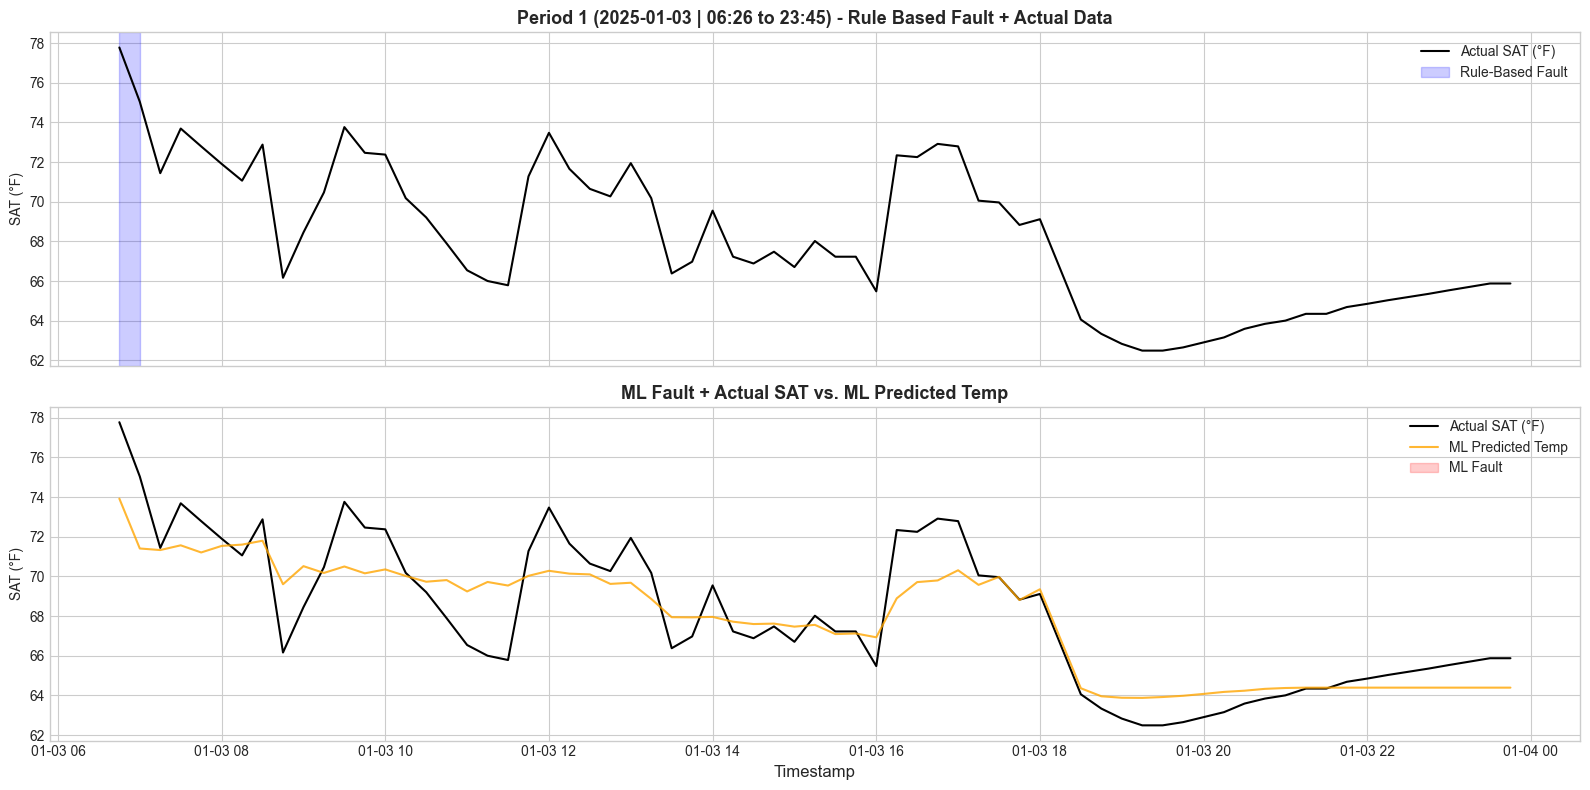

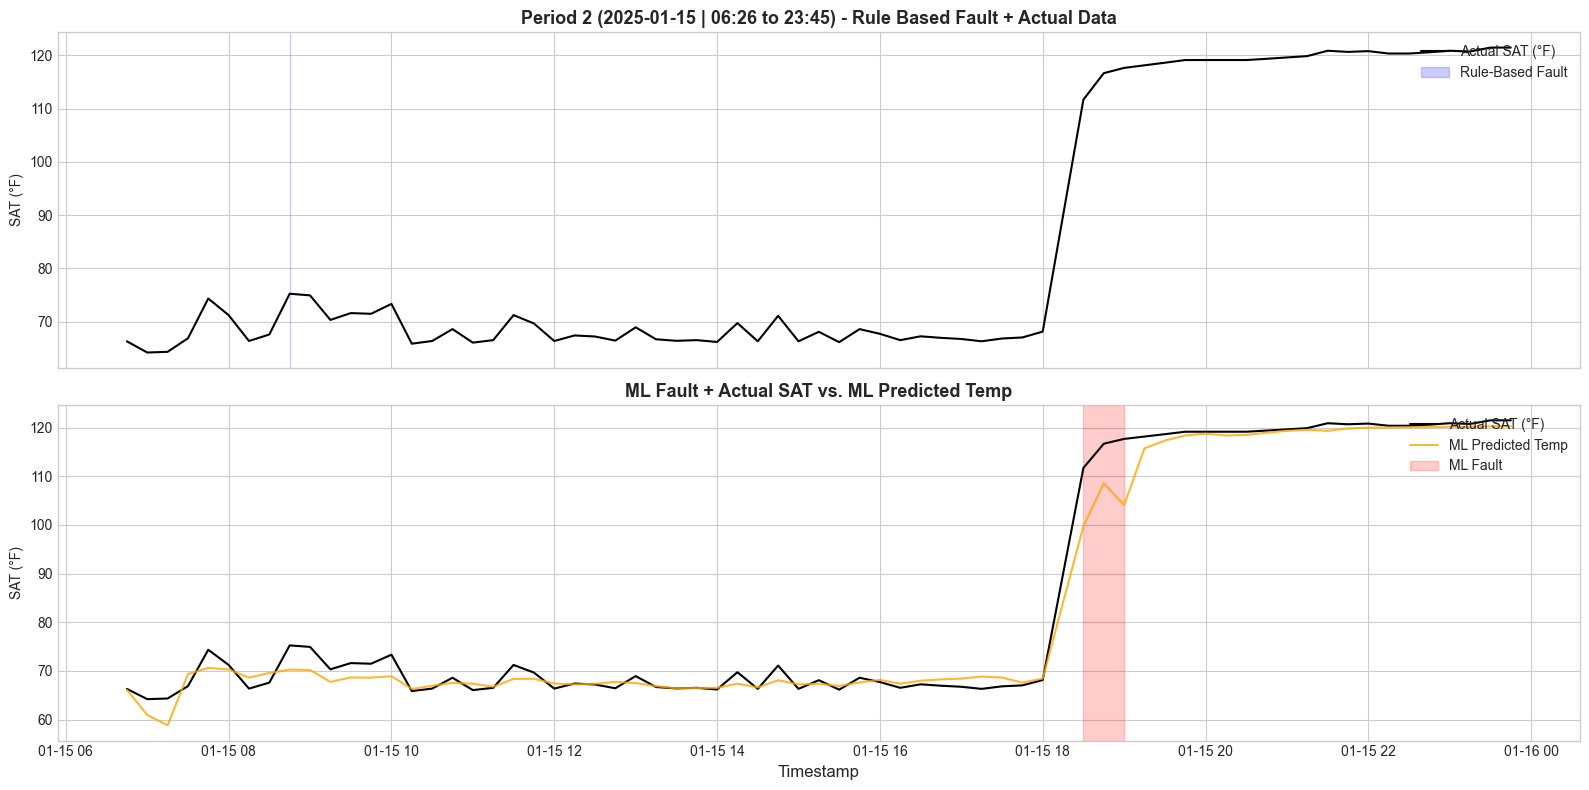

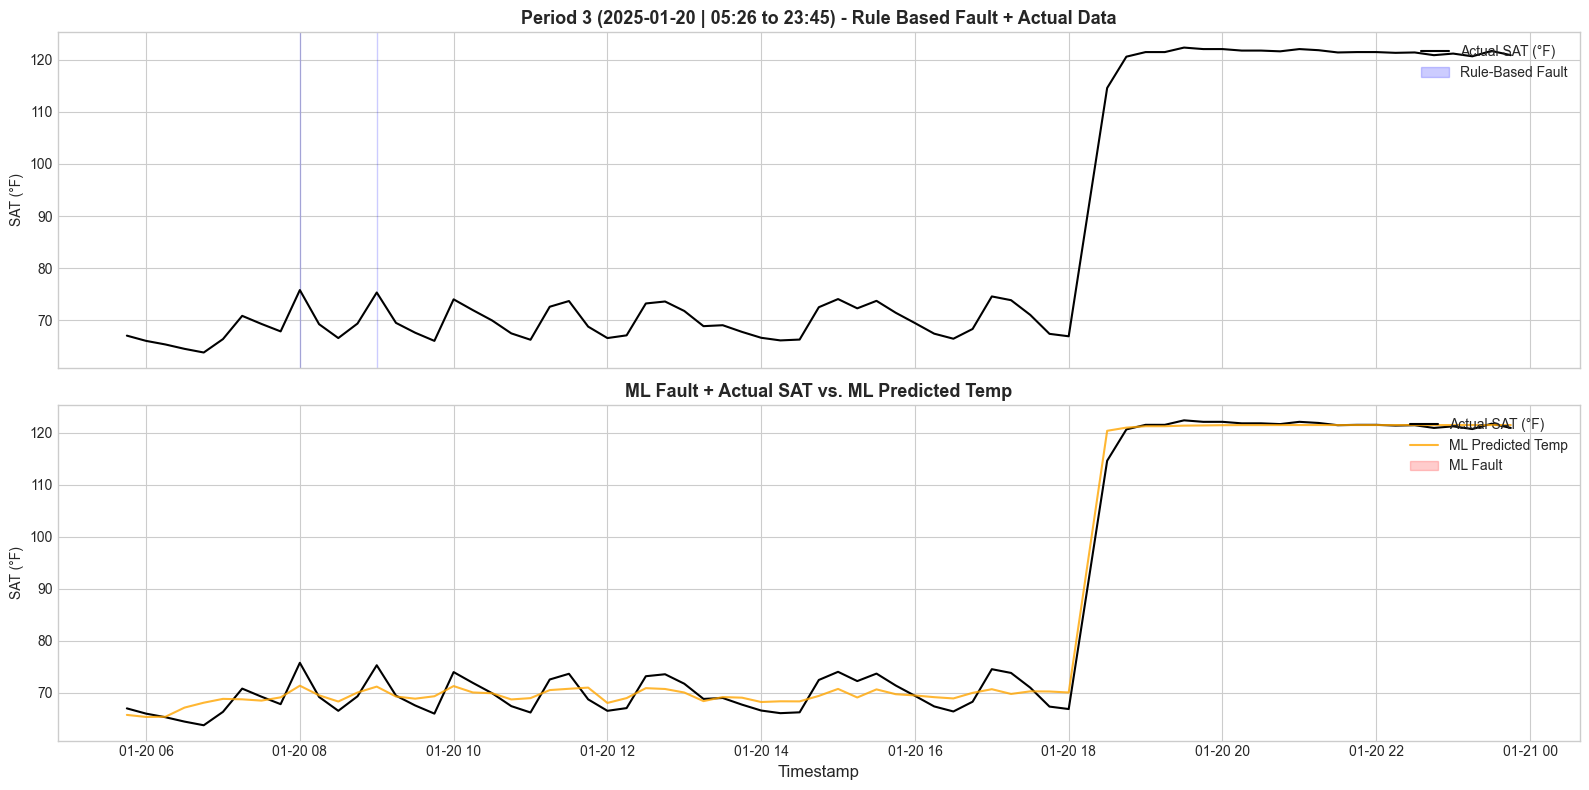

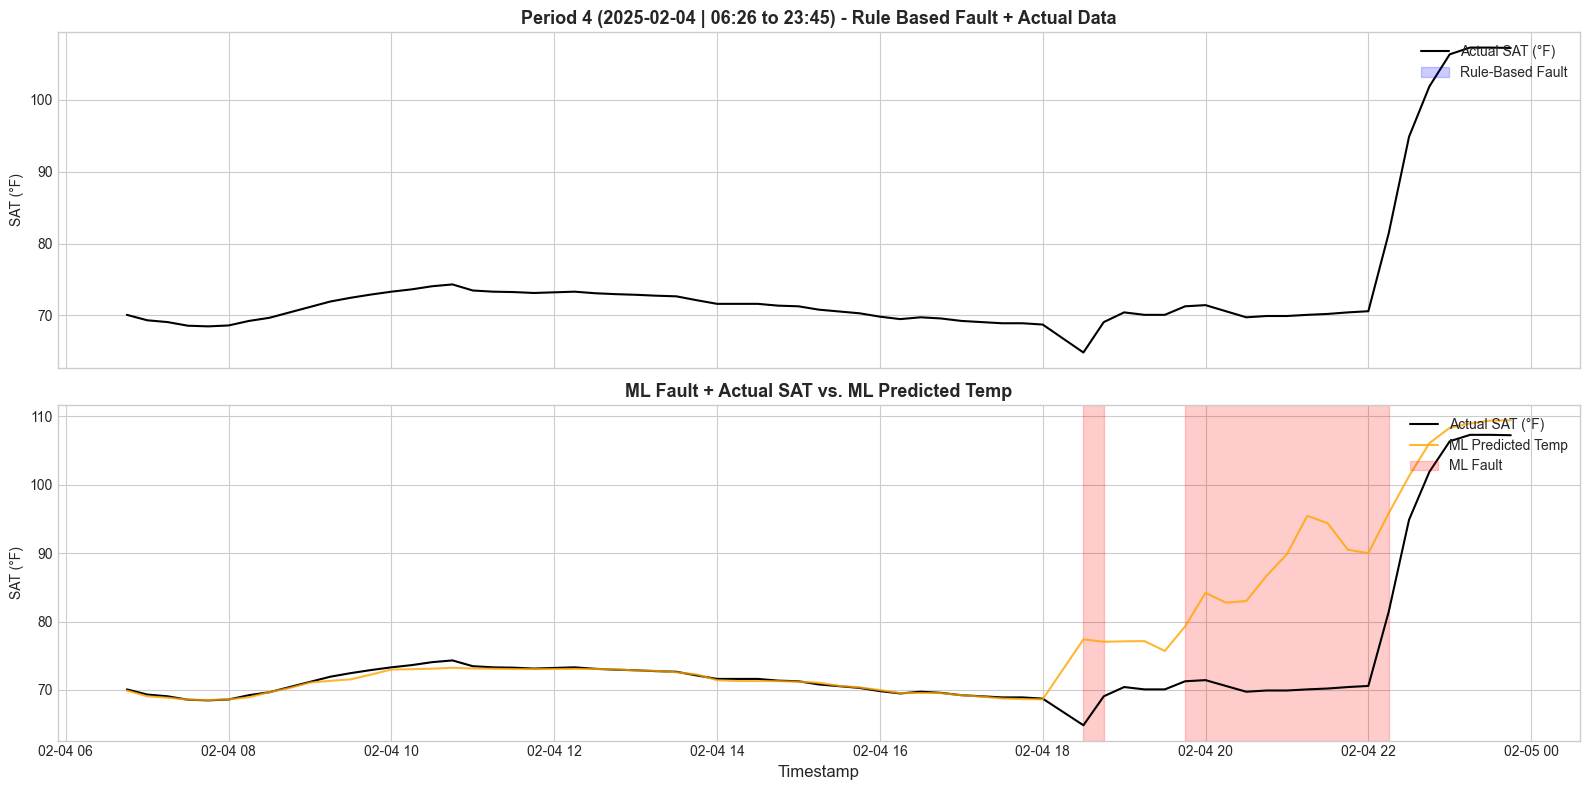

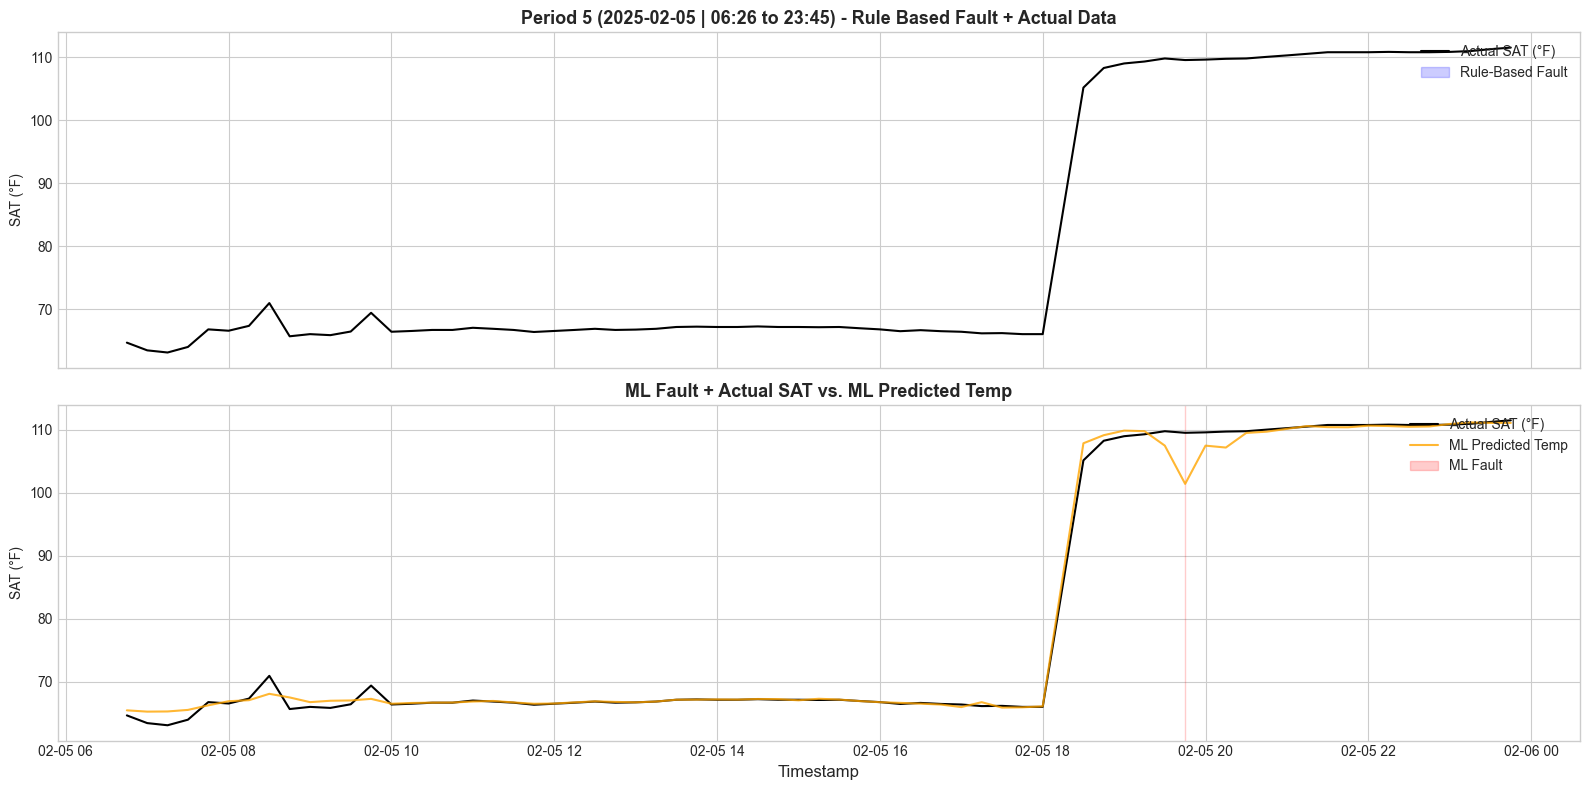

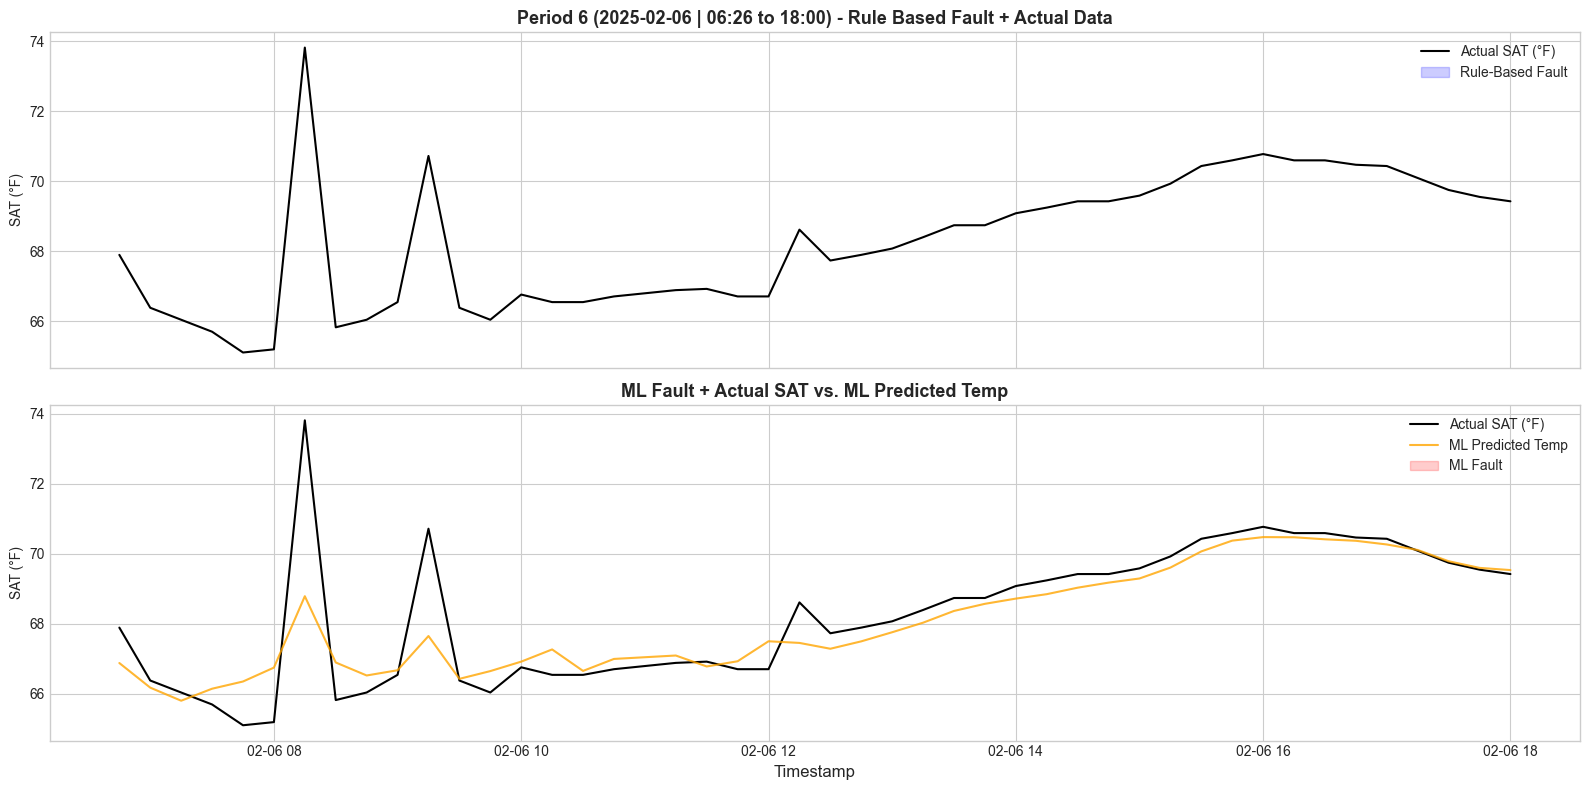

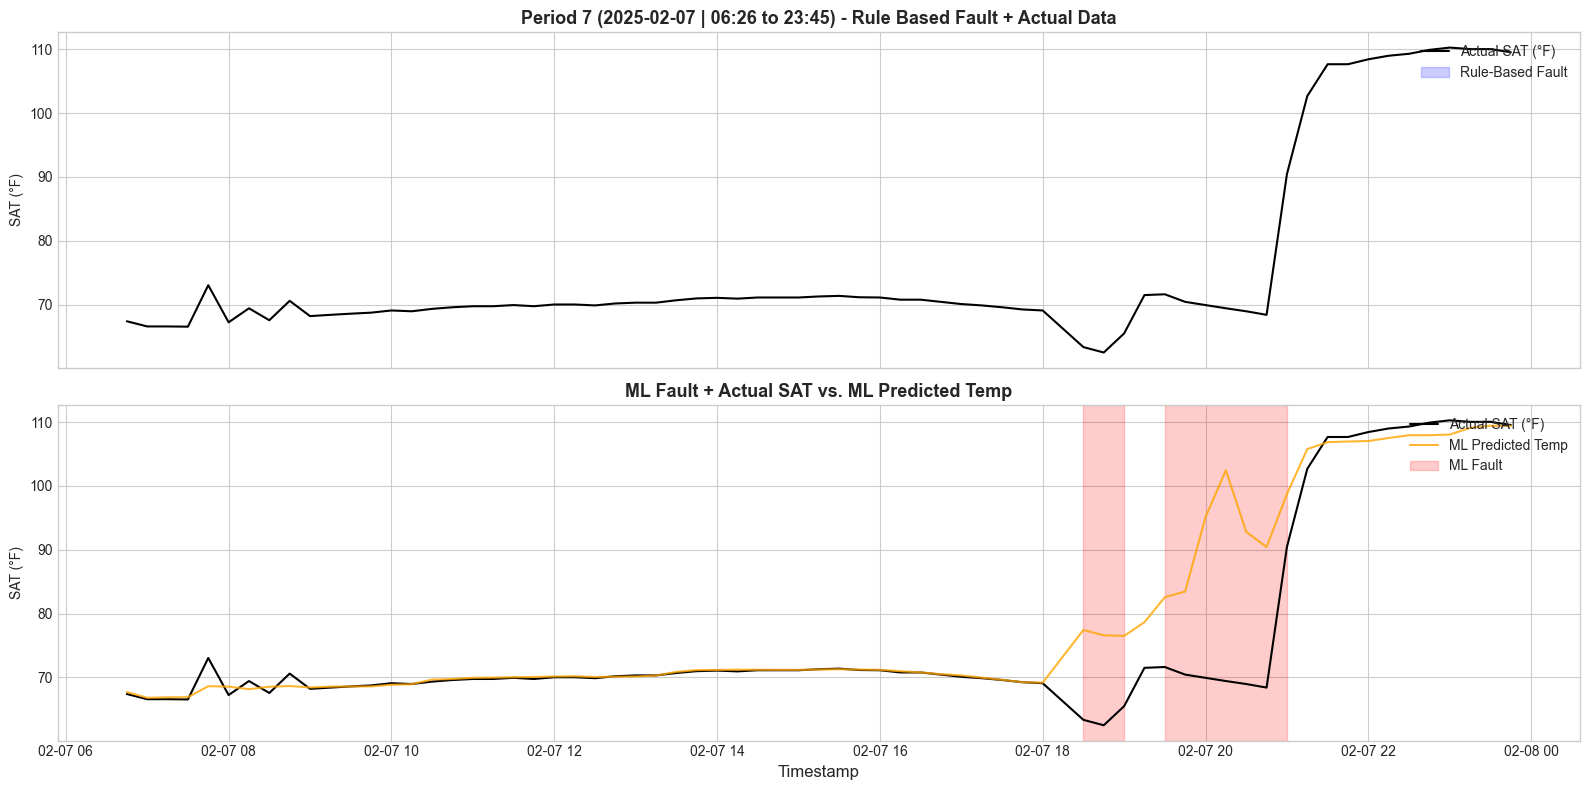

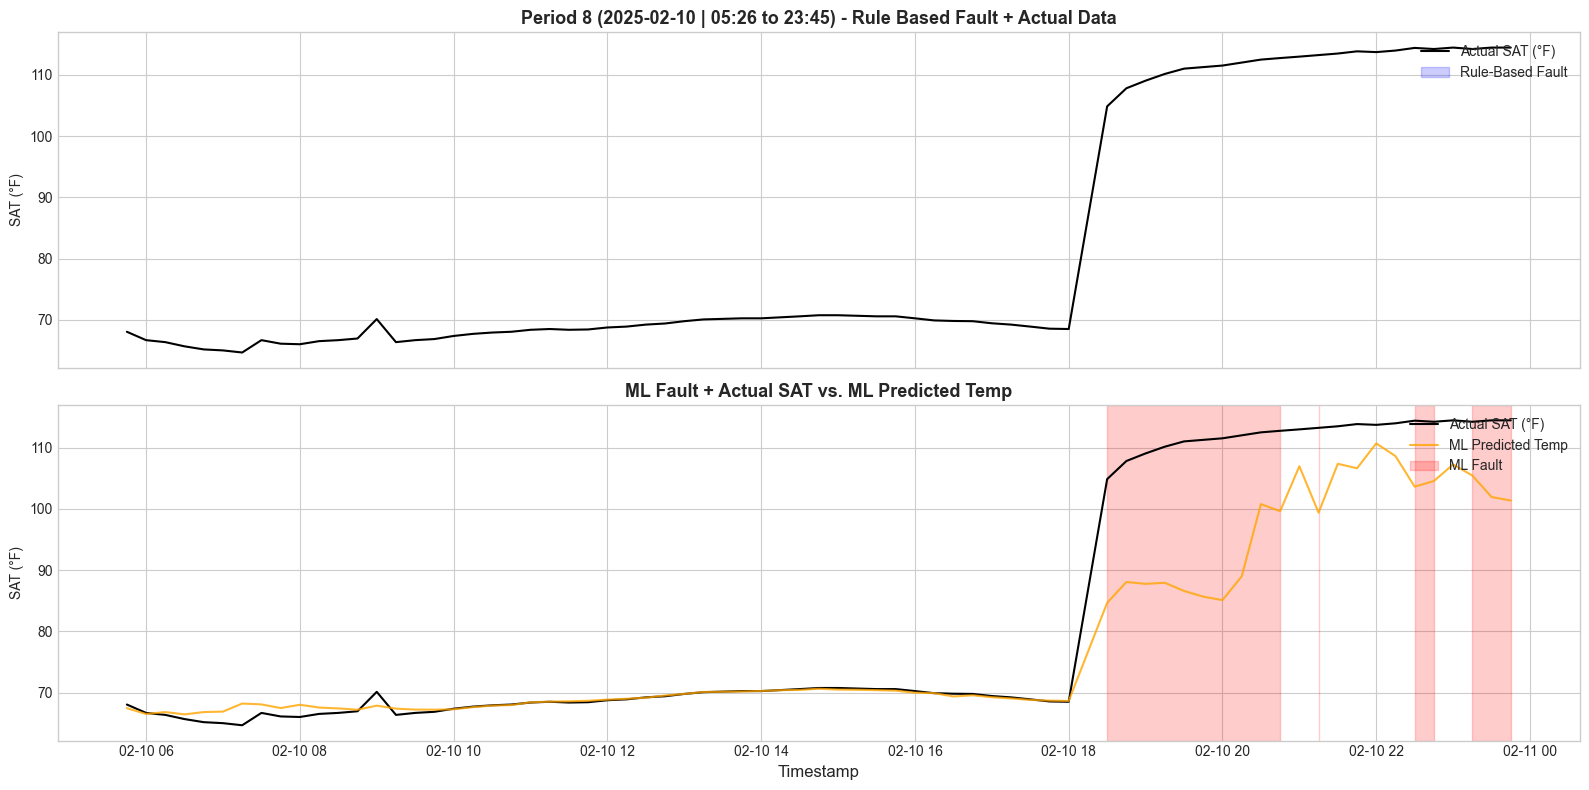

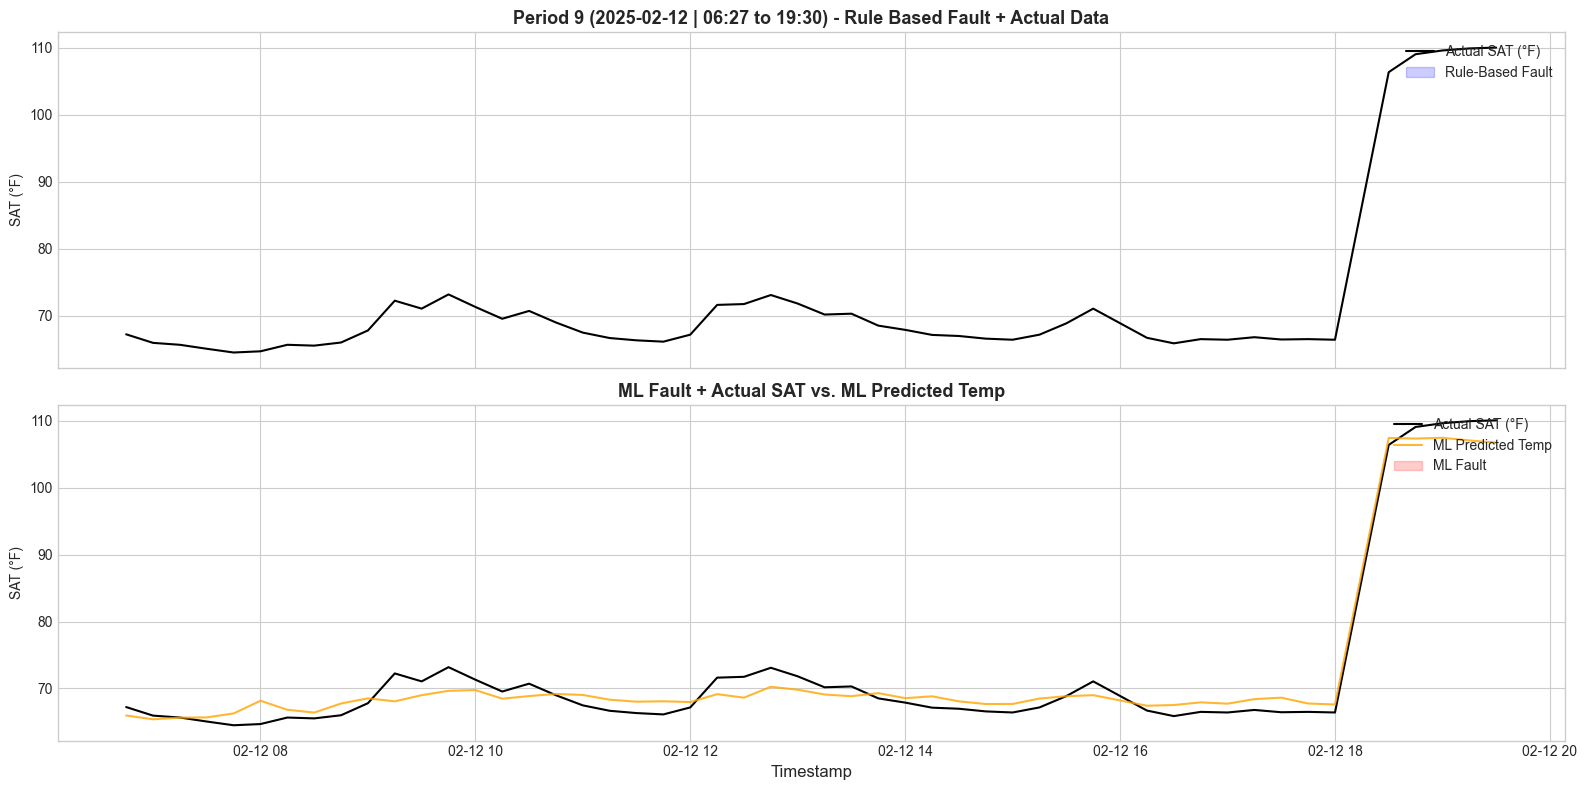

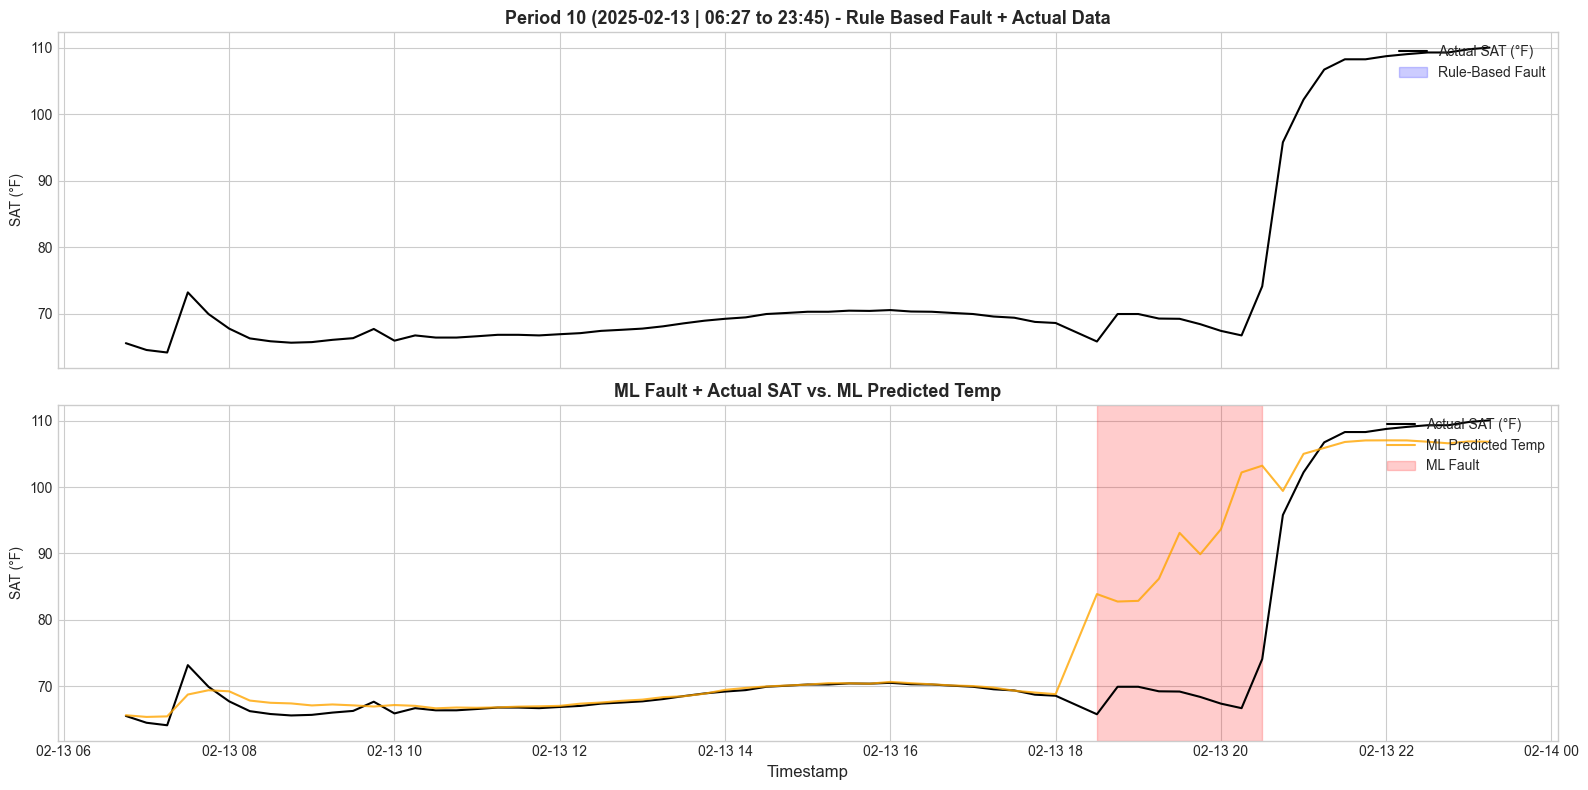

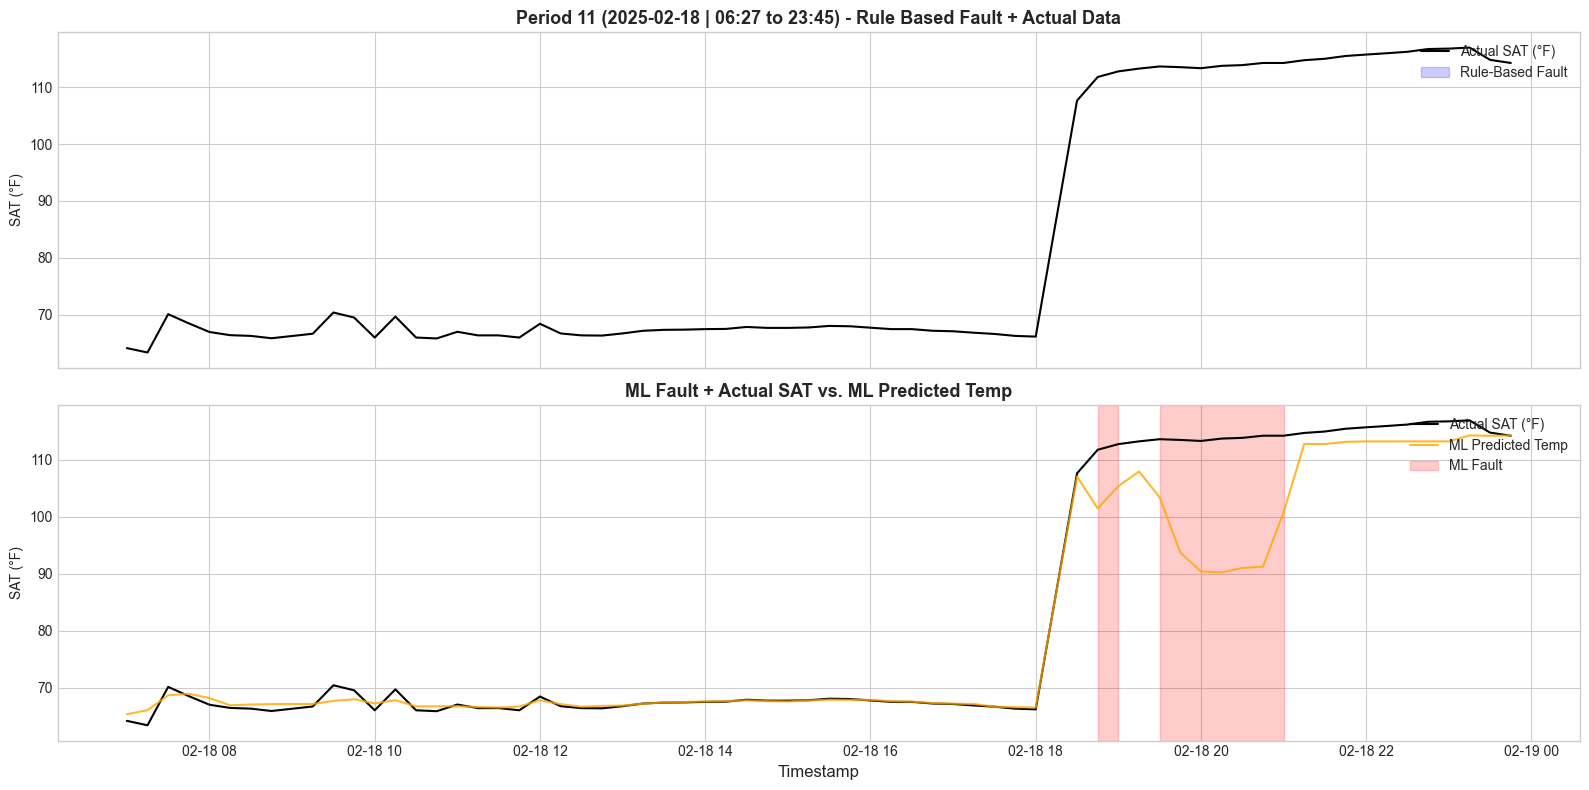

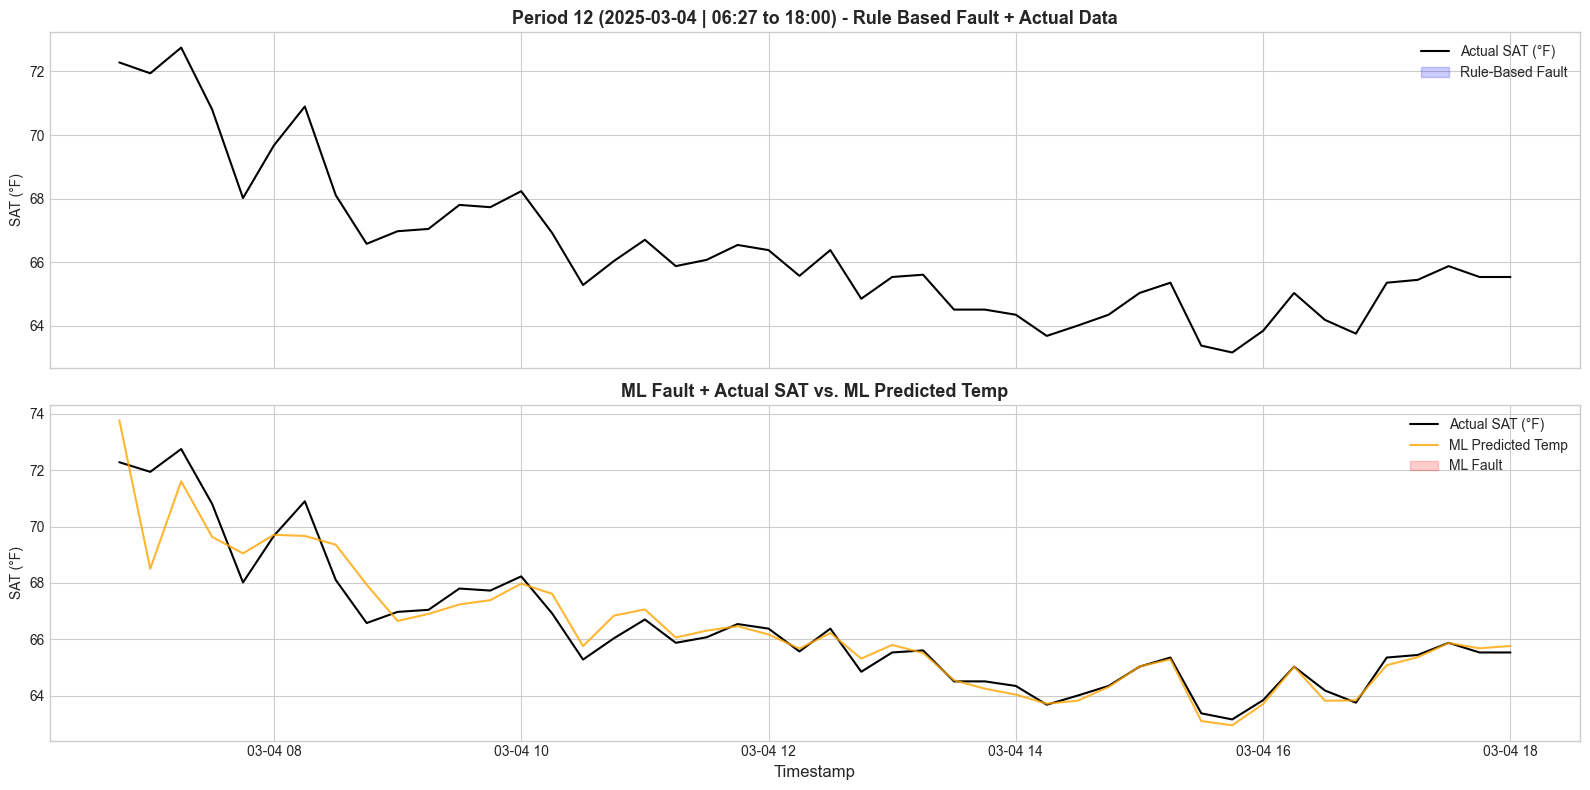

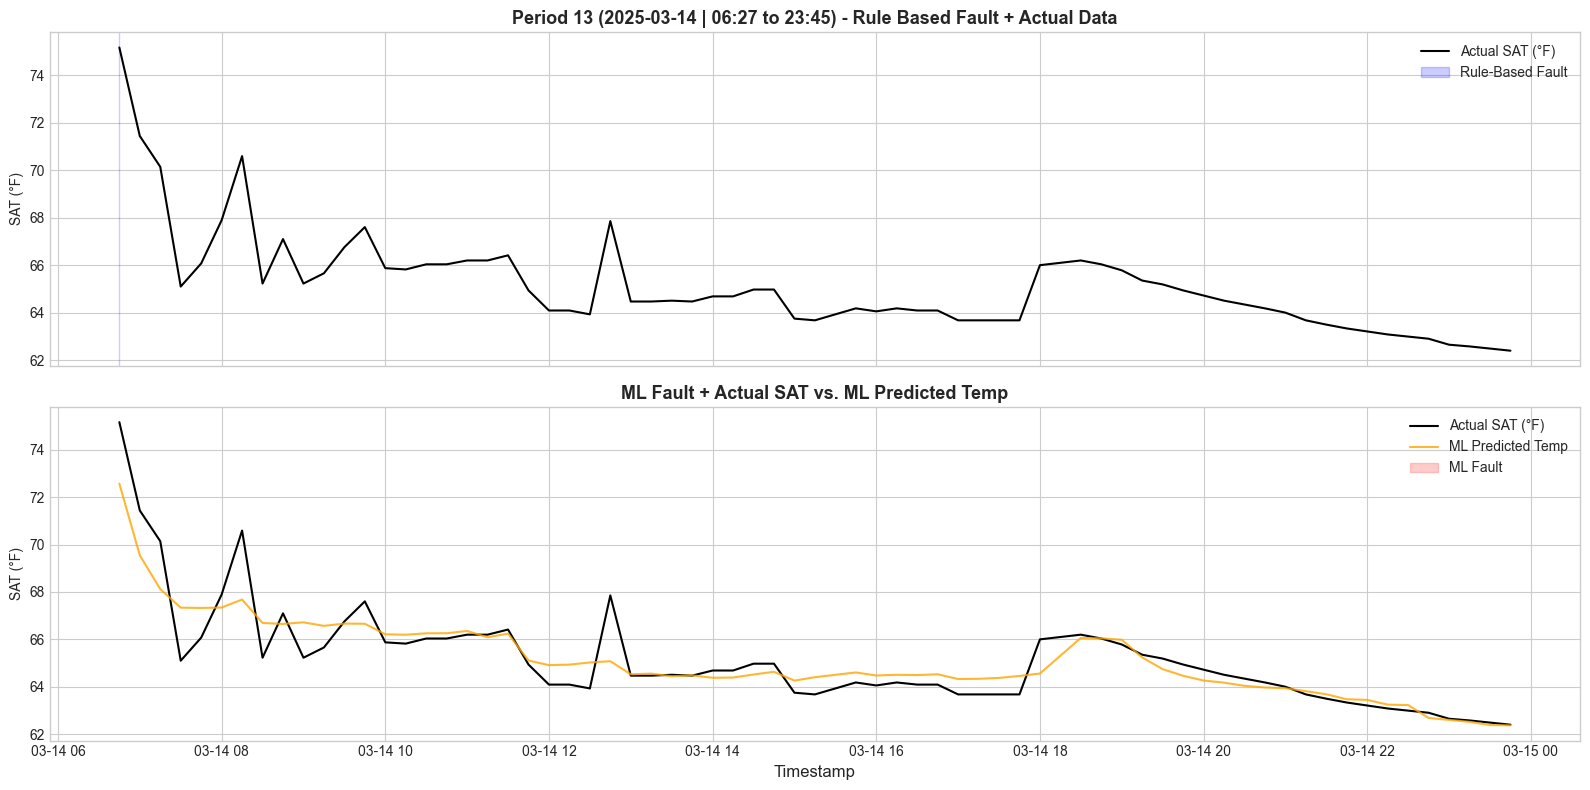

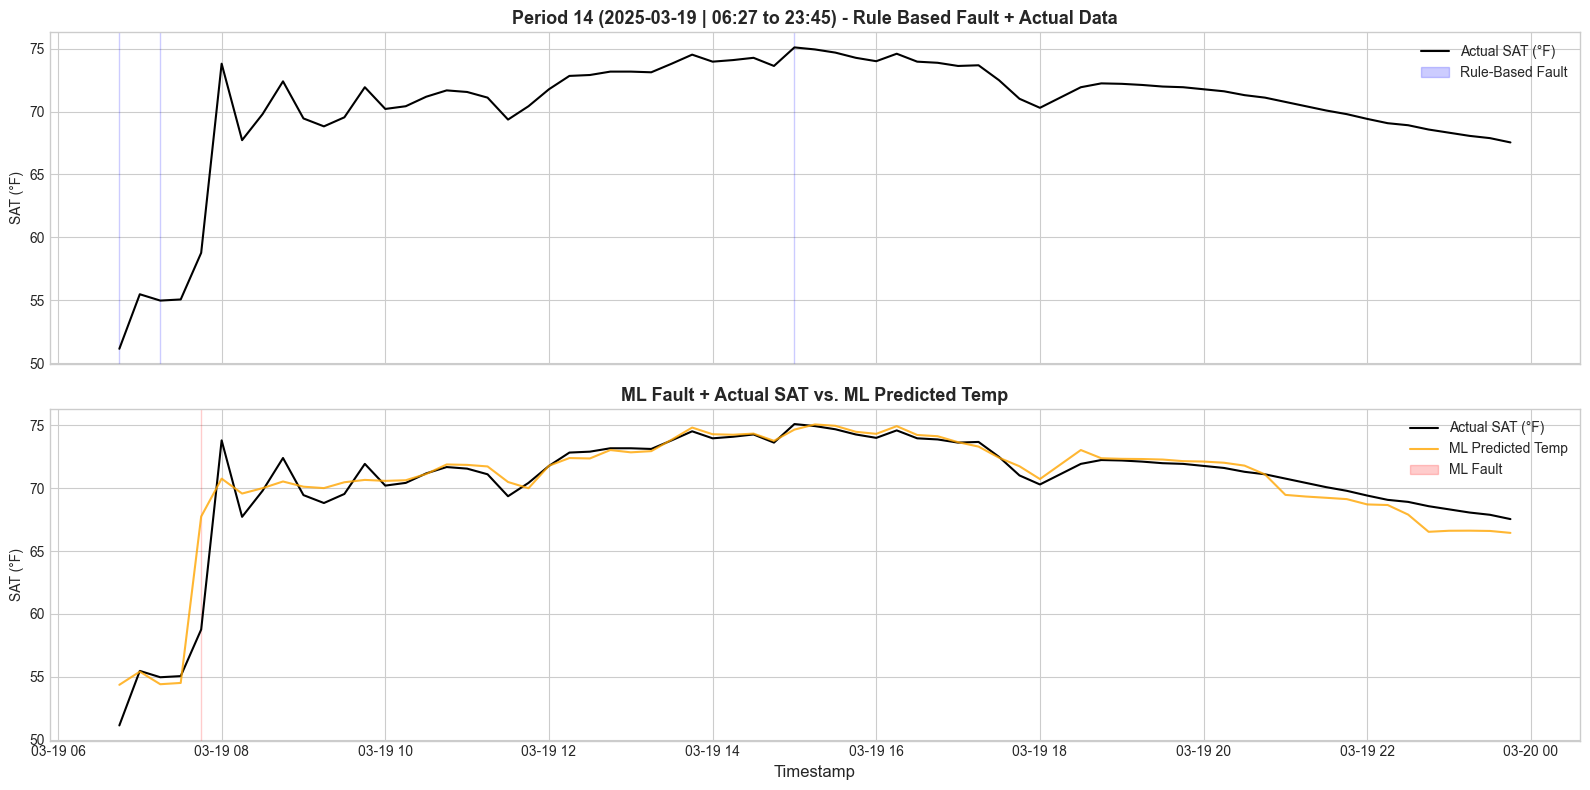

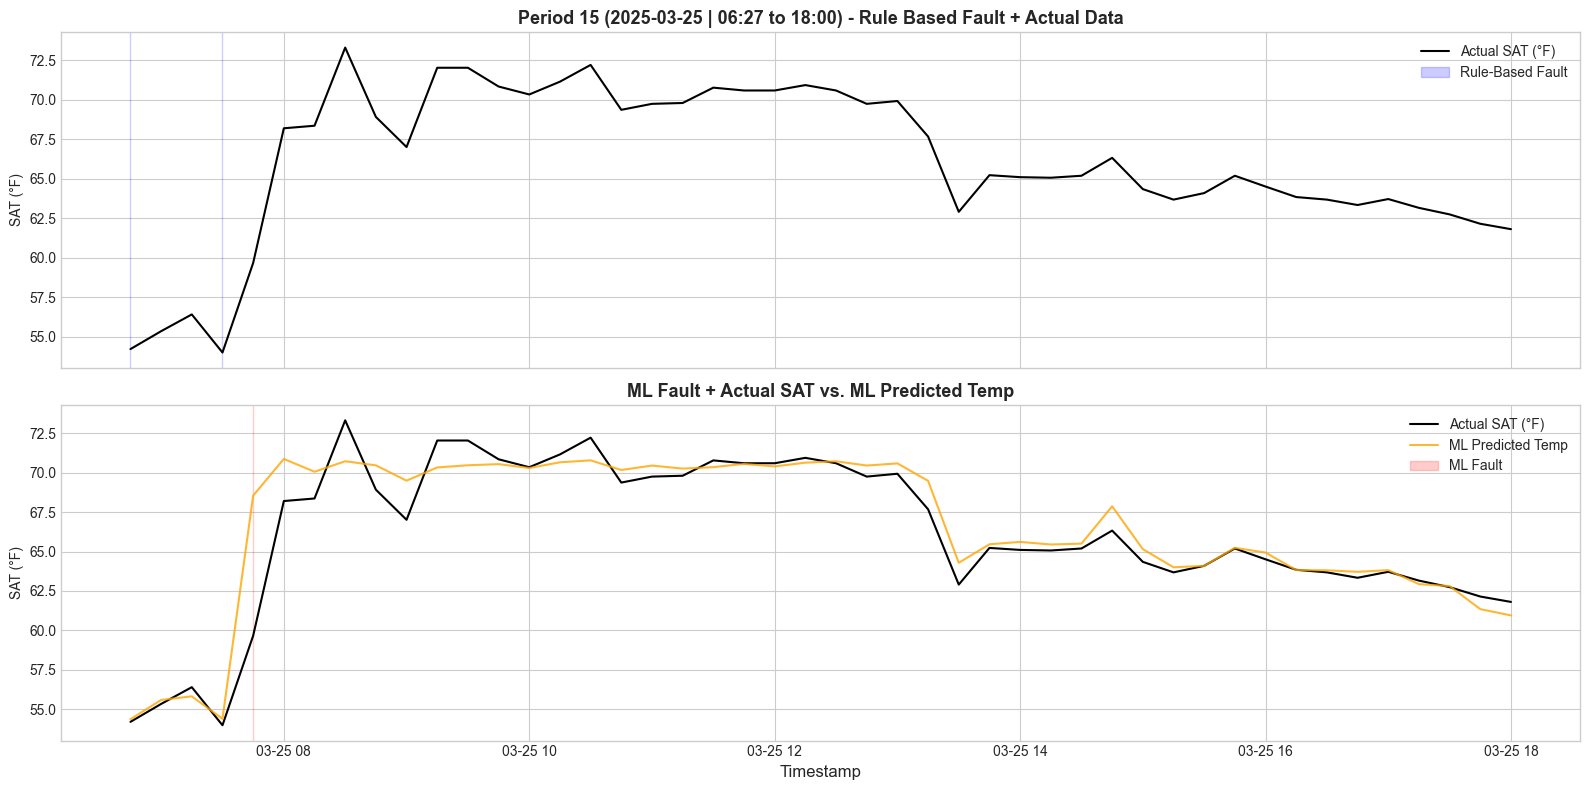

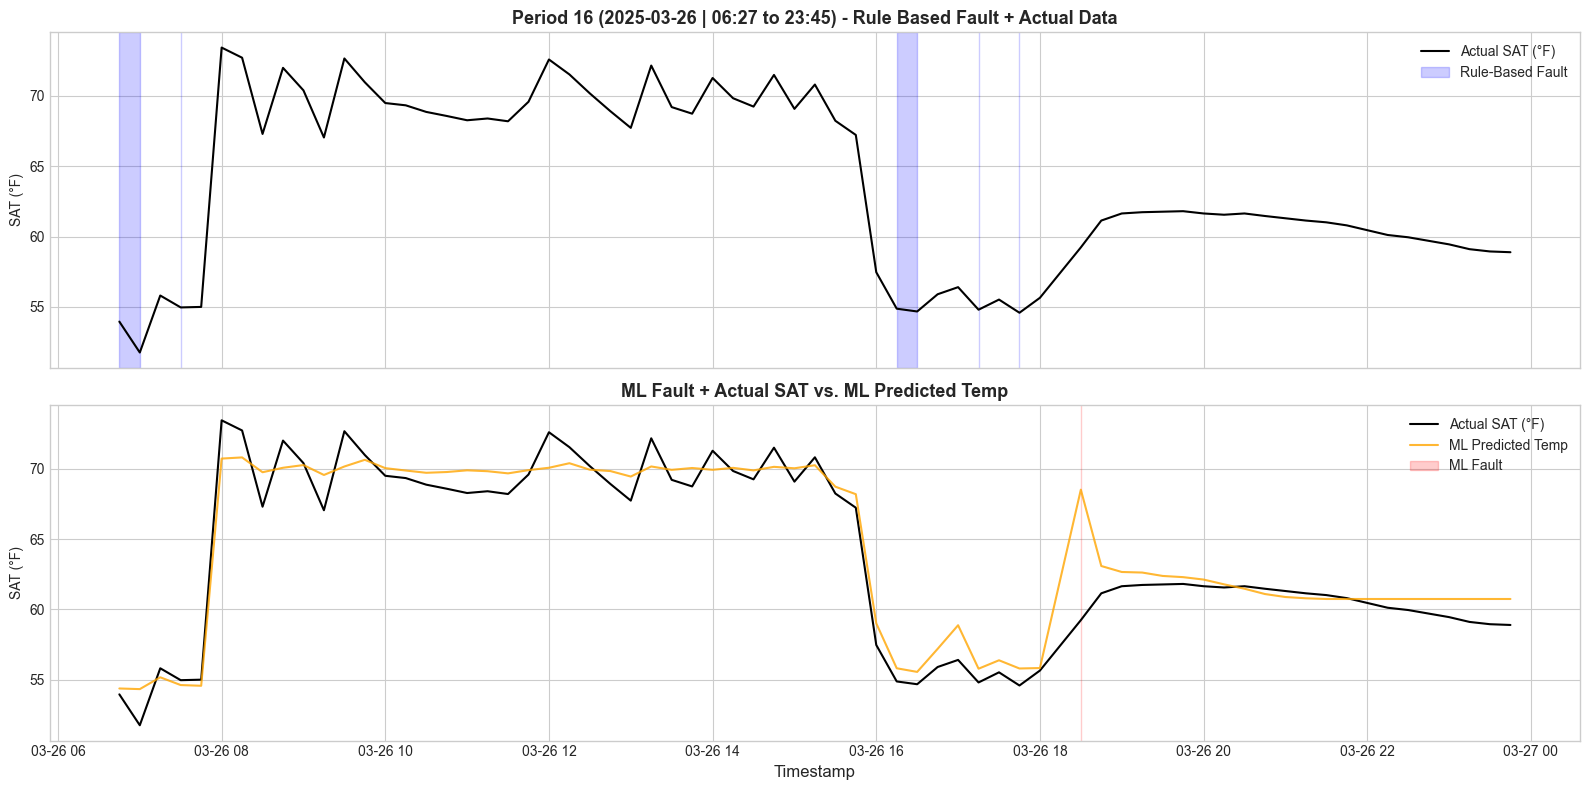

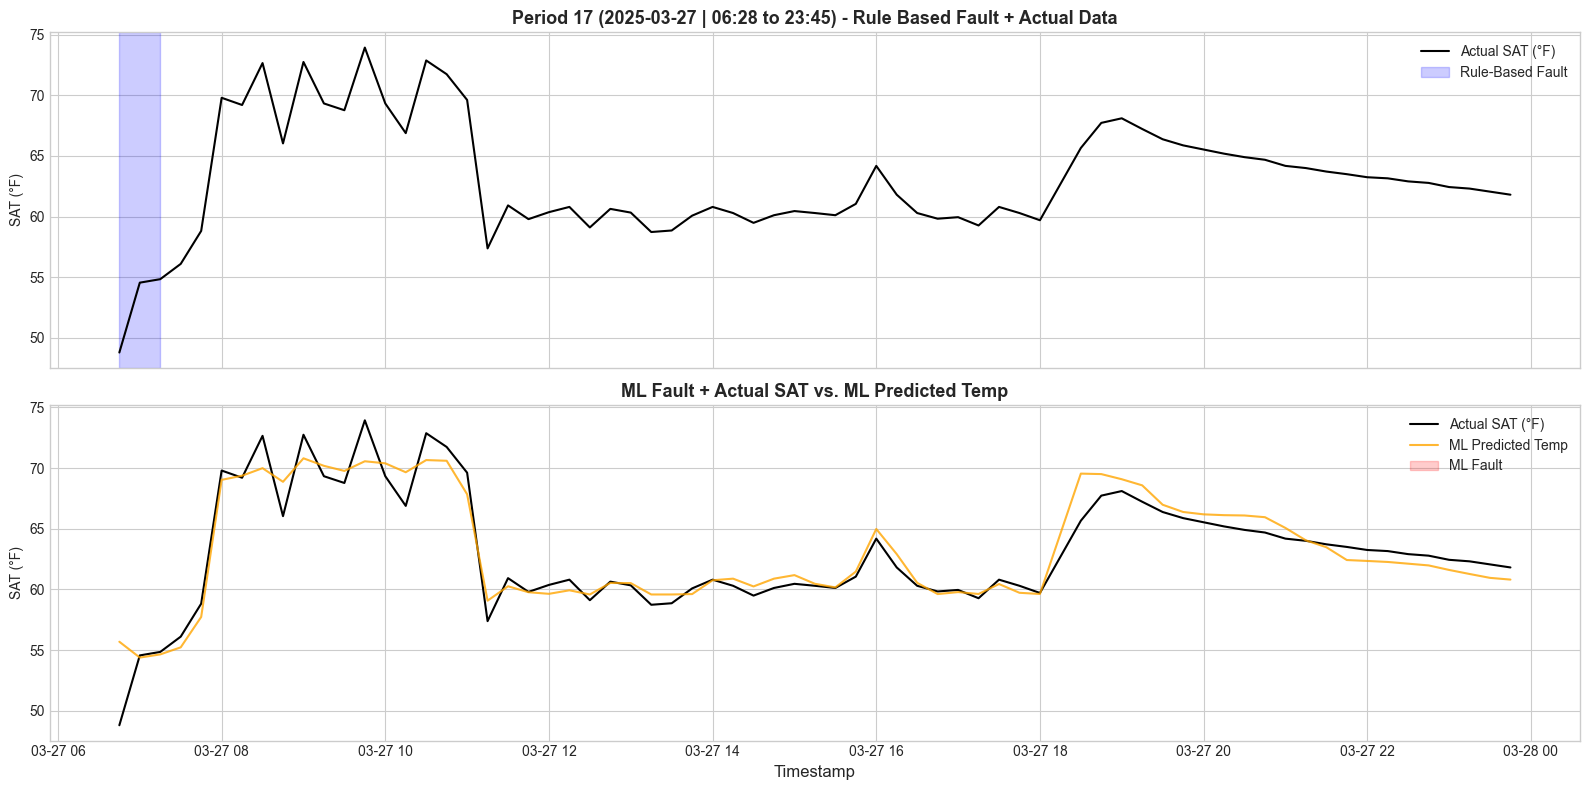

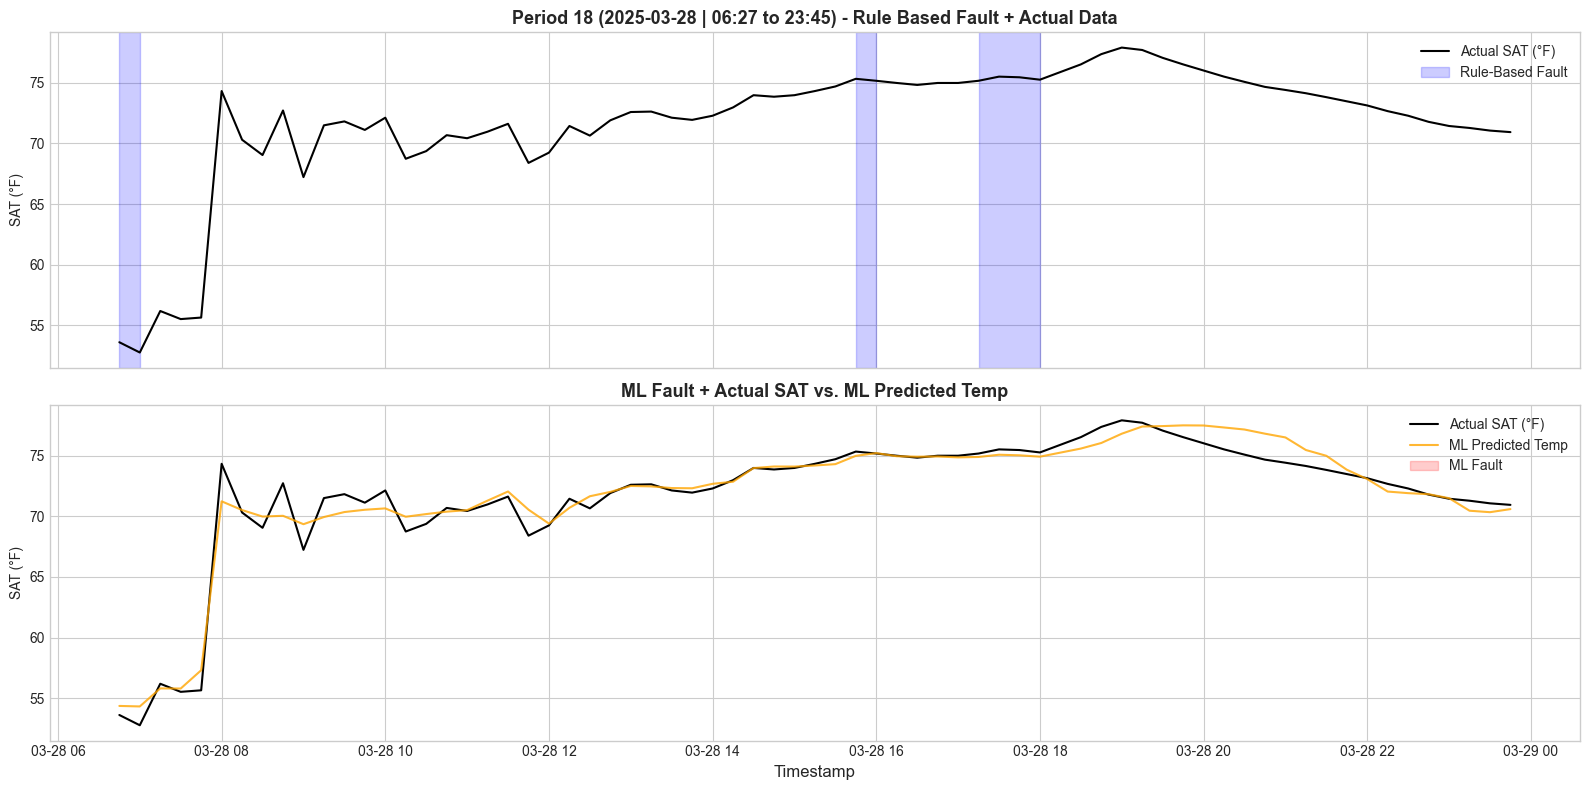

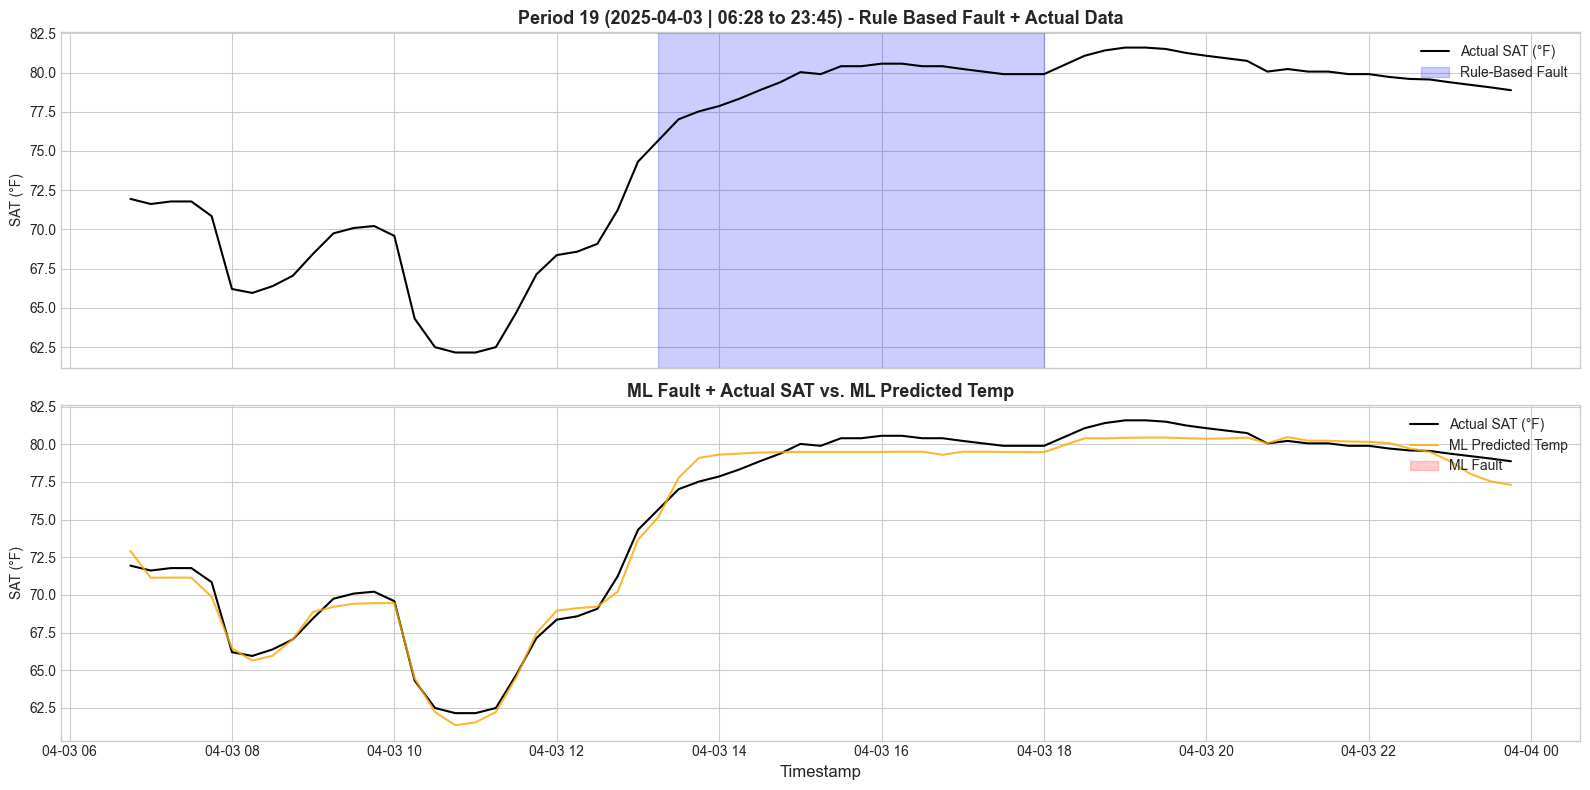

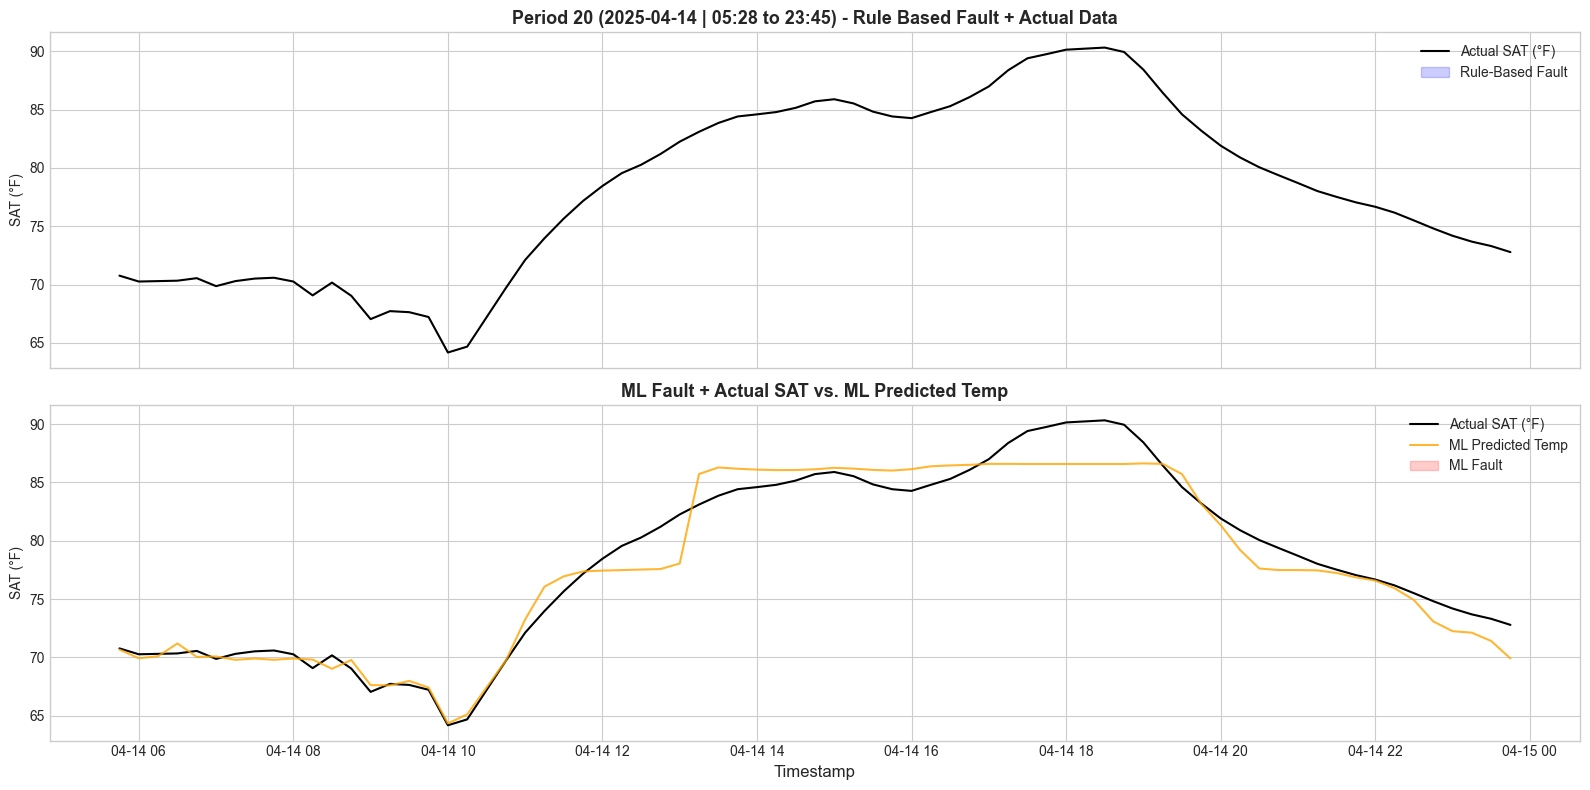

In [7]:
# ==========================================
# DEFINE FLAGS TO COMPARE
# ==========================================
RULE_FLAG_TO_COMPARE = "sat_operating_band_flag"  # The specific rule you want to graph
ML_FAULT_FLAG = "ml_residual_fault"             # The ML flag we created earlier

# --- 1. Identify Continuous Fan-On Periods ---
# Create a block ID that increments every time the fan changes state (Off -> On or On -> Off)
df_result['fan_block_id'] = (df_result['fan_on'] != df_result['fan_on'].shift(1)).cumsum()

# Group by these blocks, but only keep the ones where the fan is actually ON
fan_blocks = df_result[df_result['fan_on'] == True].groupby('fan_block_id')

time_windows = []
for _, group in fan_blocks:
    # Only keep blocks that have a decent amount of data
    if len(group) > 20: 
        start_time = group[TIMESTAMP_COL].min()
        end_time = group[TIMESTAMP_COL].max()
        time_windows.append((start_time, end_time))

print(f"Found {len(time_windows)} continuous fan-on periods (ignoring tiny blips).")

# --- 2. Loop Through Windows and Plot ---
for i, (start, end) in enumerate(time_windows):  
    
    # Slice the main dataframe for this specific time window
    window_df = df_result[(df_result[TIMESTAMP_COL] >= start) & (df_result[TIMESTAMP_COL] <= end)].copy()
    
    # Filter to where we actually have ML predictions
    plot_df = window_df.loc[window_df[ML_PRED_COL].notna()].copy()
    
    if len(plot_df) == 0:
        continue
        
    # Create the stacked subplots
    fig, (ax1, ax2) = plt.subplots(nrows=2, ncols=1, figsize=(16, 8), sharex=True)
    
    date_str = start.strftime('%Y-%m-%d')
    time_str = f"{start.strftime('%H:%M')} to {end.strftime('%H:%M')}"
    
    # ==========================================
    # Top Plot: Rule-Based FD
    # ==========================================
    ax1.plot(plot_df[TIMESTAMP_COL], plot_df[MODEL_TARGET_COL], label="Actual SAT (°F)", color="black", linewidth=1.5)
    
    # Custom blue shading for Rule-Based Faults
    ax1.fill_between(
        plot_df[TIMESTAMP_COL], 0, 1, 
        where=(plot_df[RULE_FLAG_TO_COMPARE] == 1), 
        color="blue", alpha=0.2, transform=ax1.get_xaxis_transform(), label="Rule-Based Fault"
    )
    
    ax1.set_title(f"Period {i+1} ({date_str} | {time_str}) - Rule Based Fault + Actual Data", fontsize=13, fontweight="bold")
    ax1.set_ylabel("SAT (°F)")
    ax1.legend(loc="upper right")
    
    # ==========================================
    # Bottom Plot: ML-Based FD
    # ==========================================
    ax2.plot(plot_df[TIMESTAMP_COL], plot_df[MODEL_TARGET_COL], label="Actual SAT (°F)", color="black", linewidth=1.5)
    ax2.plot(plot_df[TIMESTAMP_COL], plot_df[ML_PRED_COL], label="ML Predicted Temp", color="orange", alpha=0.8, linewidth=1.5)
    
    # Custom red shading for ML-Based Faults
    ax2.fill_between(
        plot_df[TIMESTAMP_COL], 0, 1, 
        where=(plot_df[ML_FAULT_FLAG] == 1), 
        color="red", alpha=0.2, transform=ax2.get_xaxis_transform(), label="ML Fault"
    )
    
    ax2.set_title("ML Fault + Actual SAT vs. ML Predicted Temp", fontsize=13, fontweight="bold")
    ax2.set_xlabel("Timestamp", fontsize=12)
    ax2.set_ylabel("SAT (°F)")
    ax2.legend(loc="upper right")
    
    plt.tight_layout()
    plt.show()